# Data Understanding

## Project: Retail Sales Data Analytics

This notebook focuses on understanding the structure, quality, and characteristics of the retail dataset.

The goal of this phase is to:
- Explore the dataset structure
- Identify data types and potential issues
- Detect missing values
- Analyze basic distributions
- Generate initial business insights



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Dataset Loading

The dataset was successfully loaded using pandas.

A preview of the first five rows shows that the dataset contains transaction level retail data with multiple features, including sales, profit, customer details, and product categories.

This confirms that the dataset is structured and ready for further exploration.

In [4]:
df.shape

(9994, 21)

## Dataset Size

The dataset contains 9,994 rows and 21 columns.

Each row represents an individual retail transaction, while the columns represent various attributes such as customer details, product information, and sales metrics.

This confirms that the dataset is sufficiently large for meaningful analysis.

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Missing Values Analysis

No missing values were detected across all columns in the dataset.

This indicates that the dataset is complete and does not require imputation or removal of missing data during the data cleaning phase.



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Types Overview

The dataset contains a mix of numerical and categorical features.

Most columns are correctly stored as either integer, float, or object types.

However, the Order Date and Ship Date columns are stored as object types instead of datetime format. These will need to be converted during the data cleaning phase to enable proper time-based analysis.

Overall, the dataset structure is consistent and suitable for further analysis.

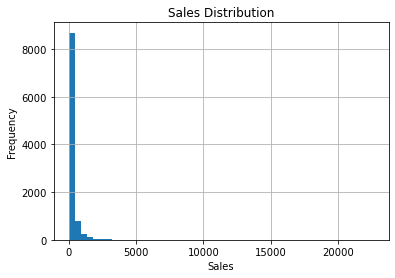

In [6]:
import matplotlib.pyplot as plt

df['Sales'].hist(bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## Sales Distribution Analysis

The sales distribution is highly right-skewed, with most transactions concentrated at low sales values and a long tail extending toward very large values.This indicates the presence of a small number of extreme high value transactions (outliers) that are much larger than the typical order size.Such a distribution is common in retail data and suggests that a disproportionate share of revenue may come from a few large purchases.

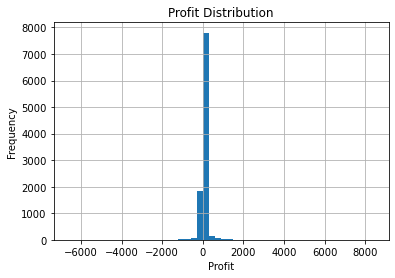

In [7]:
df['Profit'].hist(bins=50)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

## Profit Distribution Analysis

The profit distribution includes both positive and negative values, indicating that some transactions result in losses.
Most profit values are concentrated close to zero, suggesting that many transactions yield only small gains or losses.
The distribution also exhibits extreme outliers on both the positive and negative ends, representing unusually large profits and losses.This pattern indicates high variability in transaction profitability, with a small number of orders having a disproportionate impact on overall profit.

In [8]:
df['Category'].value_counts()

Office Supplies    6026
Furniture          2121
Technology         1847
Name: Category, dtype: int64

## Category Analysis

The dataset shows that Office Supplies has the highest number of transactions, followed by Furniture and Technology.

This indicates that Office Supplies dominate the retail activity in terms of order volume, while Technology has the lowest number of transactions.

However, transaction volume does not necessarily reflect revenue contribution, so further analysis of Sales and Profit by category is required to understand business performance more accurately.

In [9]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

## Sales by Category Analysis

Technology generates the highest total sales, followed by Furniture and Office Supplies.

This is an important finding because it differs from the transaction volume analysis, where Office Supplies had the most orders.

This indicates that Technology products, while lower in order frequency, contribute more revenue per transaction on average.

This highlights that high-value categories are not necessarily the most frequently purchased categories, and both volume and revenue perspectives are needed for proper business understanding.

In [10]:
df.groupby('Category')['Profit'].sum()


Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

## Profit by Category Analysis

Technology generates the highest total profit, followed closely by Office Supplies, while Furniture has the lowest profit contribution.

This indicates that although Furniture generates high sales, it is significantly less profitable compared to the other categories.

This suggests potential inefficiencies in pricing, discounting, or cost structure within the Furniture category that may need further investigation.

Overall, Technology is the strongest performing category in terms of both sales and profit.

In [11]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

## Sales by Region Analysis

The West region generates the highest total sales, followed closely by the East region. The Central region contributes moderate sales, while the South region has the lowest sales among all regions.

This indicates that business activity is not evenly distributed geographically, with the West and East regions being the primary revenue drivers.

Further analysis is required to understand whether differences in population, demand, or market strategy are influencing regional performance.

In [12]:
df.groupby('Region')['Profit'].sum()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

## Profit by Region Analysis

The West region generates the highest total profit, followed by the East region. The South and Central regions contribute significantly lower profits compared to the top-performing regions.

This indicates that the West region is the most efficient market, performing strongly in both sales and profitability.

The Central region, despite generating moderate sales, has the lowest profit contribution, suggesting potential inefficiencies in pricing, discounting, or cost structure that may need further investigation.

Overall, regional performance varies significantly in terms of profitability, highlighting the importance of region-specific business strategies.

In [13]:
df['Discount'].value_counts().sort_index()

0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: Discount, dtype: int64

## Discount Usage Analysis

The majority of transactions have either no discount (0.00) or a 0.20 discount level, indicating that these are the most commonly applied pricing strategies.

Higher discount levels (0.30 and above) are used less frequently, suggesting they are likely reserved for specific promotions or targeted sales campaigns.

This distribution indicates that discounting is not uniformly applied, and certain standard discount levels dominate the pricing strategy.

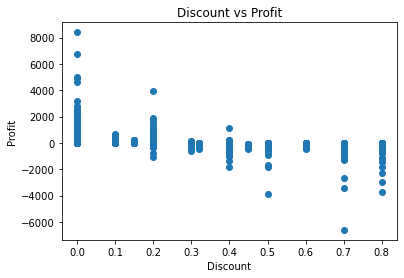

In [14]:
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

## Discount vs Profit Analysis

The scatter plot shows a negative relationship between discount levels and profit.

As the discount increases, profit tends to decrease, with higher discount levels frequently associated with negative profit values.

This suggests that excessive discounting is likely a key driver of loss-making transactions.

While discounts may help increase sales volume, they appear to significantly reduce profitability, indicating a potential trade-off between revenue growth and profit margins.

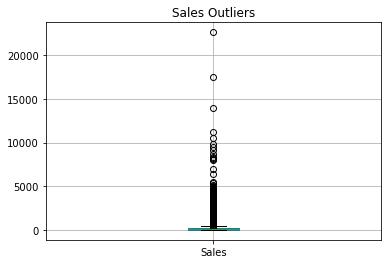

In [5]:
df.boxplot(column='Sales')
plt.title("Sales Outliers")
plt.show()

## Sales Outliers Analysis

The boxplot of Sales reveals a significant number of outliers above the upper whisker.

Most transactions are concentrated at lower sales values, as indicated by the compressed box near the bottom of the plot. However, there are numerous high-value transactions extending far beyond the typical range, with some exceeding 20,000.

This confirms that the Sales distribution contains extreme values, which contribute to the previously observed right-skewness.

These high-value transactions may represent bulk purchases or premium product sales and have a substantial impact on overall revenue.

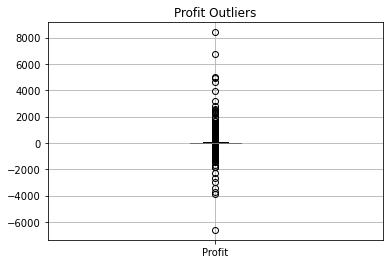

In [8]:
df.boxplot(column='Profit')
plt.title("Profit Outliers")
plt.show()

## Profit Outliers Analysis

The boxplot of Profit reveals the presence of outliers on both the negative and positive sides.

There are several extreme negative values, with losses reaching approximately -6500, indicating that some transactions result in substantial financial losses.

Similarly, there are extreme positive values, with profits exceeding 8000, suggesting that a small number of transactions generate significantly high returns.

This indicates that profitability is highly variable across transactions, with both high-risk losses and high-reward gains present in the dataset.

Such variability highlights the importance of identifying factors—such as discounts, product categories, or regions—that contribute to loss-making and high-profit transactions.

## Data Understanding Summary

Key observations from the dataset include:

- The dataset contains no missing values and is structurally complete.
- Sales are highly right-skewed, with a small number of high-value transactions driving overall revenue.
- Profit includes both positive and negative values, indicating that not all transactions are profitable.
- Technology is the strongest performing category in terms of both sales and profit, while Furniture shows weaker profitability.
- The West region performs best in both sales and profit, while the Central region shows lower profitability.
- Discounting is a common pricing strategy, particularly at 0.00 and 0.20 levels.
- Higher discount levels are associated with reduced profitability, suggesting that excessive discounting contributes to losses.
- Both Sales and Profit exhibit significant outliers, indicating the presence of extreme transactions that impact overall performance.

These insights provide a strong foundation for the data cleaning and feature engineering phases, where further refinement and transformation of the data will be performed.